## FAS Classification
ViT-L/14@336px · GAC-depth4 · MixUp · DropPath · 4-Model Ensemble · SupCon · Zero-Shot · KNN · 20-TTA · 3-Round Pseudo

---
Referensi Paper: https://arxiv.org/pdf/2501.01720

Dokumentasi yang lebih readable: https://gist.github.com/tamamfb/744417b1bf8ac1cf709f9c989fa62774

---
Install library yang dibutuhkan: CLIP (OpenAI), albumentations 2.0.8, scikit-learn, matplotlib, seaborn, pandas, Pillow, tqdm.

In [1]:
import subprocess, sys
for p in ['git+https://github.com/openai/CLIP.git', 'albumentations==2.0.8',
           'scikit-learn', 'matplotlib', 'seaborn', 'pandas', 'Pillow', 'tqdm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', p])
print('done')


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


done



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


---
Import semua library (PyTorch, CLIP, Albumentations, sklearn) serta mendefinisikan helper `_coarse_dropout()`.

> _coarse_dropout() dibuat sebagai wrapper karena Albumentations 2.0.8 mengubah parameter CoarseDropout dari max_holes/max_height/max_width menjadi num_holes_range/hole_height_range/hole_width_range. Wrapper ini menyembunyikan detail API baru agar kode lebih bersih. from torch.amp import autocast, GradScaler digunakan (bukan torch.cuda.amp) karena versi lama sudah deprecated di PyTorch terbaru.

In [2]:
import os, random, warnings, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast, GradScaler

import clip
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import types
warnings.filterwarnings('ignore')

def _coarse_dropout(max_holes=8, max_height=32, max_width=32, min_holes=1, fill_value=0, p=0.3):
    return A.CoarseDropout(
        num_holes_range=(min_holes, max_holes),
        hole_height_range=(8, max_height),
        hole_width_range=(8, max_width),
        fill=fill_value, p=p)

print(f'torch {torch.__version__}  albumentations {A.__version__}')

torch 2.8.0+cu129  albumentations 2.0.8


---
Semua hyperparameter dan path dalam satu dictionary CONFIG (disini kita pakai Modal Notebook, dengan GPU NVIDIA H200)

#### Highlight:
1. `batch_size=64`: NVIDIA H200 memiliki 141 GB VRAM, jauh lebih besar dari GPU konsumer, sehingga batch besar memungkinkan gradient yang lebih stabil. we have to push the limit right?
2. `accum_steps=2`: Effective batch = 128, untuk menjaga stabilitas training tanpa terlalu banyak memory overhead.
3. `gac_depth=4, num_queries=96`: Lebih dalam dari versi sebelumnya (depth=3, queries=64) karena VRAM lebih besar memungkinkan model yang lebih kapasitas.
4. `drop_path=0.1`: Stochastic depth sebagai regularizer, mencegah overfitting di GAC layers.
5. `mixup_alpha=0.2, mixup_prob=0.5`: MixUp augmentation untuk meningkatkan generalisasi.
6. `label_smoothing=0.08`: Sedikit lebih tinggi dari versi sebelumnya (0.05) untuk regularisasi tambahan.
7. `lr_clip_p3=3e-8`: Sangat kecil agar fine-tuning seluruh 24 blok CLIP tidak merusak pretrained features.
8. `val_split=0.10`: 10% untuk validasi agar lebih banyak data training.
9. `tta_steps=20`: untuk prediksi final yang lebih stabil.
10. `pseudo_conf_r1/r2/r3`: 3 round pseudo-labeling dengan threshold turun bertahap (0.998 → 0.97 → 0.92).

In [ ]:
BASE_DIR = '/data/fas'
OUT_DIR  = '/outputs/v5'
os.makedirs(OUT_DIR, exist_ok=True)

CONFIG = {
    'train_dir':         f'{BASE_DIR}/train',
    'test_dir':          f'{BASE_DIR}/test',
    'sample_submission': f'{BASE_DIR}/samplesubmission.csv',
    'output_dir':        OUT_DIR,

    'model_name':  'ViT-L/14@336px',
    'image_size':  336,
    'batch_size':  64,
    'num_workers': 8,
    'accum_steps': 2,
    'grad_clip':   1.0,

    'phase1_epochs': 35,
    'lr_connector':  3e-4,
    'lr_classifier': 1e-3,
    'patience_p1':   12,

    'phase2_epochs':  30,
    'n_unfreeze_p2':  12,
    'lr_clip_p2':     5e-7,
    'lr_conn_p2':     5e-6,
    'lr_cls_p2':      5e-5,
    'patience_p2':    10,

    'phase3_epochs':  20,
    'n_unfreeze_p3':  24,
    'lr_clip_p3':     3e-8,
    'lr_conn_p3':     5e-7,
    'lr_cls_p3':      5e-6,
    'patience_p3':    8,

    'weight_decay':    1e-2,
    'label_smoothing': 0.08,
    'alpha_loss':      0.6,
    'focal_gamma':     2.0,
    'supcon_weight':   0.2,
    'supcon_temp':     0.07,

    'num_queries': 96,
    'gac_heads':   8,
    'gac_depth':   4,
    'drop_path':   0.1,

    'mixup_alpha': 0.2,
    'mixup_prob':  0.5,

    'seed':      42,
    'val_split': 0.10,
    'tta_steps': 20,

    'pseudo_conf_r1':   0.998,
    'pseudo_conf_r2':   0.97,
    'pseudo_conf_r3':   0.92,
    'pseudo_epochs_r1': 12,
    'pseudo_epochs_r2': 10,
    'pseudo_epochs_r3': 8,
    'patience_ps':      5,

    'w_nn':  0.55,
    'w_zs':  0.25,
    'w_knn': 0.20,

    'label_mapping': {
        'fake_printed':   'fake_print',
        'realperson':     'realperson',
        'fake_mannequin': 'fake_mannequin',
        'fake_mask':      'fake_mask',
        'fake_screen':    'fake_screen',
        'fake_unknown':   'fake_unknown',
    },
    'classes': ['realperson','fake_print','fake_screen','fake_mask','fake_mannequin','fake_unknown'],
}

CLIP_MEAN = [0.48145466, 0.4578275,  0.40821073]
CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]
CLASS2IDX = {c: i for i, c in enumerate(CONFIG['classes'])}
IDX2CLASS = {i: c for c, i in CLASS2IDX.items()}

TEXT_PROMPTS = {
    'realperson':    ['a real human face', 'a live genuine person face photo',
                      'a real person looking at camera', 'a genuine human face'],
    'fake_print':    ['a photo of a printed face', 'a paper face attack photo',
                      'face printed on paper held up', 'a printed photograph of a face'],
    'fake_screen':   ['a face shown on a screen', 'a digital display showing a face',
                      'face replay attack on monitor', 'a phone screen showing a face'],
    'fake_mask':     ['a person wearing a face mask', 'a 3D silicone face mask',
                      'a rigid face mask worn on head', 'a fake face mask spoofing attack'],
    'fake_mannequin':['a mannequin head face', 'a dummy plastic face',
                      'a mannequin face spoofing attack', 'an artificial dummy head'],
    'fake_unknown':  ['an unknown face spoofing attack', 'a fake artificial face',
                      'a face anti-spoofing attack', 'a synthetic fake face'],
}

INFER_BATCH = 16

print('CONFIG Nvidia H200 loaded.')
print(f'  model_name : {CONFIG["model_name"]}')
print(f'  image_size : {CONFIG["image_size"]}')
print(f'  batch_size : {CONFIG["batch_size"]} (eff {CONFIG["batch_size"]*CONFIG["accum_steps"]})')
print(f'  gac_depth  : {CONFIG["gac_depth"]}  num_queries: {CONFIG["num_queries"]}')

---
Set random seed di semua library (Python, NumPy, PyTorch) serta cek GPU.

In [4]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    g = torch.cuda.get_device_properties(0)
    print(f'GPU   : {g.name}')
    print(f'VRAM  : {g.total_memory/1e9:.1f} GB')
    print(f'CUDA  : {torch.version.cuda}')

Device: cuda
GPU   : NVIDIA H200
VRAM  : 150.1 GB
CUDA  : 12.9


---
Baca semua gambar training dari folder, buat DataFrame dengan kolom `path`, `label`, `label_idx`. Baca test images. Hitung class weights untuk mengatasi class imbalance.

In [5]:
def load_dataset_info(train_dir, label_mapping):
    records = []
    for folder in sorted(Path(train_dir).iterdir()):
        if not folder.is_dir() or folder.name not in label_mapping: continue
        label = label_mapping[folder.name]
        for p in sorted(folder.iterdir()):
            if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}:
                records.append({'path': str(p), 'label': label, 'label_idx': CLASS2IDX[label]})
    df = pd.DataFrame(records)
    print(f'Train: {len(df)}')
    print(df['label'].value_counts().to_string())
    return df

def load_test_info(test_dir):
    records = [{'id': p.stem, 'path': str(p)}
               for p in sorted(Path(test_dir).iterdir())
               if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}]
    df = pd.DataFrame(records).sort_values('id').reset_index(drop=True)
    print(f'Test : {len(df)}')
    return df

train_df = load_dataset_info(CONFIG['train_dir'], CONFIG['label_mapping'])
test_df  = load_test_info(CONFIG['test_dir'])

cw_np = compute_class_weight('balanced', classes=np.arange(len(CONFIG['classes'])),
                              y=train_df['label_idx'].values)
CLASS_WEIGHTS = torch.tensor(cw_np, dtype=torch.float32)
print('Class weights:', {c: round(w,3) for c, w in zip(CONFIG['classes'], cw_np)})

Train: 1648
label
realperson        424
fake_unknown      356
fake_mask         292
fake_mannequin    230
fake_screen       204
fake_print        142
Test : 404
Class weights: {'realperson': np.float64(0.648), 'fake_print': np.float64(1.934), 'fake_screen': np.float64(1.346), 'fake_mask': np.float64(0.941), 'fake_mannequin': np.float64(1.194), 'fake_unknown': np.float64(0.772)}


---
Definisi augmentasi training, validasi, 20-step TTA, dan fungsi mixup_data()

1. Train transform agresif: RandomResizedCrop(scale=(0.5,1.0)) lebih lebar dari sebelumnya untuk paksa model belajar dari crop yang lebih beragam. GaussNoise dan RandomRotate90 ditambahkan untuk diversity lebih.

2. Val transform minimal: hanya resize + center crop + normalize, tanpa augmentasi agar evaluasi konsisten.

3. TTA (20 step): Kombinasi center crop, horizontal flip, berbagai skala resize, color jitter, gaussian blur. Rata-rata dari 20 augmentasi berbeda memberikan prediksi yang lebih robust daripada single inference.

4. MixUp: lam ~ Beta(0.2, 0.2) menginterpolasi dua gambar dan labelnya. Terbukti meningkatkan generalisasi karena model belajar distribusi yang lebih smooth, bukan keputusan hard boundary.

In [ ]:
def get_train_transform(image_size):
    return A.Compose([
        A.RandomResizedCrop(size=(image_size, image_size), scale=(0.5, 1.0)),
        A.HorizontalFlip(p=0.5),
        A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1, p=0.8),
        A.GaussianBlur(blur_limit=(3, 7), p=0.3),
        A.ToGray(p=0.1),
        A.GridDistortion(p=0.2),
        A.RandomRotate90(p=0.1),
        A.GaussNoise(p=0.2),
        _coarse_dropout(max_holes=8, max_height=48, max_width=48, min_holes=1, p=0.3),
        A.Normalize(mean=CLIP_MEAN, std=CLIP_STD),
        ToTensorV2(),
    ])

def get_val_transform(image_size):
    rt = int(image_size * 1.143)
    return A.Compose([
        A.Resize(height=rt, width=rt),
        A.CenterCrop(height=image_size, width=image_size),
        A.Normalize(mean=CLIP_MEAN, std=CLIP_STD),
        ToTensorV2(),
    ])

def get_tta_transforms(image_size):
    rt  = int(image_size * 1.143)
    rt2 = int(image_size * 1.25)
    rt3 = int(image_size * 1.05)
    norm = [A.Normalize(mean=CLIP_MEAN, std=CLIP_STD), ToTensorV2()]
    return [
        A.Compose([A.Resize(height=rt,  width=rt),  A.CenterCrop(height=image_size, width=image_size)] + norm),
        A.Compose([A.Resize(height=rt,  width=rt),  A.CenterCrop(height=image_size, width=image_size), A.HorizontalFlip(p=1.0)] + norm),
        A.Compose([A.RandomResizedCrop(size=(image_size, image_size), scale=(0.85, 1.0))] + norm),
        A.Compose([A.RandomResizedCrop(size=(image_size, image_size), scale=(0.85, 1.0)), A.HorizontalFlip(p=1.0)] + norm),
        A.Compose([A.Resize(height=rt2, width=rt2), A.CenterCrop(height=image_size, width=image_size)] + norm),
        A.Compose([A.Resize(height=rt2, width=rt2), A.CenterCrop(height=image_size, width=image_size), A.HorizontalFlip(p=1.0)] + norm),
        A.Compose([A.RandomResizedCrop(size=(image_size, image_size), scale=(0.9, 1.0)), A.ColorJitter(brightness=0.1, contrast=0.1, p=1.0)] + norm),
        A.Compose([A.RandomResizedCrop(size=(image_size, image_size), scale=(0.9, 1.0)), A.ColorJitter(brightness=0.1, contrast=0.1, p=1.0), A.HorizontalFlip(p=1.0)] + norm),
        A.Compose([A.PadIfNeeded(min_height=image_size+40, min_width=image_size+40, border_mode=0, fill=0), A.CenterCrop(height=image_size, width=image_size)] + norm),
        A.Compose([A.Resize(height=image_size, width=image_size)] + norm),
        A.Compose([A.Resize(height=image_size, width=image_size), A.HorizontalFlip(p=1.0)] + norm),
        A.Compose([A.RandomResizedCrop(size=(image_size, image_size), scale=(0.75, 0.9))] + norm),
        A.Compose([A.RandomResizedCrop(size=(image_size, image_size), scale=(0.75, 0.9)), A.HorizontalFlip(p=1.0)] + norm),
        A.Compose([A.Resize(height=rt,  width=rt),  A.CenterCrop(height=image_size, width=image_size), A.ColorJitter(brightness=0.15, contrast=0.15, p=1.0)] + norm),
        A.Compose([A.Resize(height=rt,  width=rt),  A.CenterCrop(height=image_size, width=image_size), A.ColorJitter(brightness=0.15, contrast=0.15, p=1.0), A.HorizontalFlip(p=1.0)] + norm),
        A.Compose([A.Resize(height=rt3, width=rt3), A.CenterCrop(height=image_size, width=image_size)] + norm),
        A.Compose([A.Resize(height=rt3, width=rt3), A.CenterCrop(height=image_size, width=image_size), A.HorizontalFlip(p=1.0)] + norm),
        A.Compose([A.RandomResizedCrop(size=(image_size, image_size), scale=(0.95, 1.0))] + norm),
        A.Compose([A.RandomResizedCrop(size=(image_size, image_size), scale=(0.95, 1.0)), A.HorizontalFlip(p=1.0)] + norm),
        A.Compose([A.Resize(height=rt2, width=rt2), A.CenterCrop(height=image_size, width=image_size), A.GaussianBlur(blur_limit=(3,5), p=1.0)] + norm),
    ]

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

print('Transforms ready (336px, 20-TTA, MixUp).')

Transforms ready (336px, 20-TTA, MixUp).


---
Class `FASDataset` (PyTorch Dataset), fungsi `build_dataloaders()` dengan `WeightedRandomSampler`

> WeightedRandomSampler memastikan setiap batch memiliki distribusi kelas yang seimbang meski data aslinya imbalanced. Ini lebih baik dari oversampling naif karena sampling dilakukan per-batch secara random. persistent_workers=True (saat num_workers>0) menjaga worker process tetap hidup antar epoch, menghemat overhead spawn process.

In [7]:
class FASDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_test = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = np.array(Image.open(row['path']).convert('RGB'))
        except Exception:
            sz = CONFIG['image_size']
            img = np.full((sz, sz, 3), 128, dtype=np.uint8)
        if self.transform:
            img = self.transform(image=img)['image']
        return (img, row['id']) if self.is_test else (img, int(row['label_idx']))


def build_dataloaders(df, image_size, val_split, batch_size, num_workers, seed):
    tr_idx, va_idx = train_test_split(
        np.arange(len(df)), test_size=val_split,
        stratify=df['label_idx'].values, random_state=seed)
    df_tr = df.iloc[tr_idx].reset_index(drop=True)
    df_va = df.iloc[va_idx].reset_index(drop=True)
    print(f'Train {len(df_tr)} | Val {len(df_va)}')
    sw = CLASS_WEIGHTS[df_tr['label_idx'].values]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    kw = dict(num_workers=num_workers, pin_memory=True, persistent_workers=num_workers>0)
    tr_loader = DataLoader(FASDataset(df_tr, get_train_transform(image_size)),
                           batch_size=batch_size, sampler=sampler, drop_last=True, **kw)
    va_loader = DataLoader(FASDataset(df_va, get_val_transform(image_size)),
                           batch_size=batch_size*2, shuffle=False, **kw)
    return tr_loader, va_loader, df_va


train_loader, val_loader, df_val = build_dataloaders(
    train_df, CONFIG['image_size'], CONFIG['val_split'],
    CONFIG['batch_size'], CONFIG['num_workers'], CONFIG['seed'])
print(f'Batches — train {len(train_loader)} | val {len(val_loader)}')

Train 1483 | Val 165
Batches — train 23 | val 2


---
#### Arsitektur lengkap model. Ini adalah implementasi paper I-FAS (AAAI 2025) yang dimodifikasi.

1. `CLIPExtractor`: Menggunakan ViT-L/14@336px dari OpenAI CLIP sebagai backbone. Hook di setiap ResidualAttentionBlock mengcapture CLS token dari semua 24 layer (bukan hanya output akhir). Ini mengikuti paper I-FAS yang menunjukkan bahwa multi-level features lebih informatif untuk face anti-spoofing. encode_image_for_zs() di-fix dengan _cls_buf.clear() sebelum dan sesudah untuk mencegah memory leak akibat hooks terus menumpuk tensor.

2. `DropPath`: Stochastic depth, jadi saat training, setiap residual connection di GACLayer di-drop secara random dengan probabilitas drop_path. Ini memaksa model tidak bergantung pada satu path tertentu, mirip prinsip Dropout tapi pada level layer. Probability meningkat secara linear dengan depth (deeper layers lebih sering di-drop).

3. `GACLayer`: Globally Aware Connector layer dengan tiga sub-modul = Self-Attention (SA), Cross-Attention (CA), dan Feed-Forward (FF). SA memungkinkan queries saling attend, CA memungkinkan queries attend ke local features dari CLIP. DropPath diterapkan ke output setiap sub-modul.

4. `EnhancedGAC`: Stack 4 GACLayer (depth=4). Query bank (nn.Parameter) diinisialisasi kecil (×0.02) untuk stabilitas awal. CLS tokens dari semua 24 layer di-concatenate dengan queries sebagai context.

5. `FASClassifier`: AdaptiveAvgPool + LayerNorm + 2-layer MLP dengan shortcut connection. Shortcut dari pooled features langsung ke logits memastikan gradient flow yang baik bahkan saat MLP layers dalam kondisi buruk. Dropout 0.4 lebih tinggi dari sebelumnya untuk regularisasi lebih kuat.

6. `IFASModelV5`: Wrapper model lengkap. proj_head menghasilkan 256-dim L2-normalized embeddings untuk SupCon loss. trainable_params() mengumpulkan semua parameter yang perlu di-update berdasarkan phase training.

In [8]:
class CLIPExtractor(nn.Module):
    def __init__(self, model_name='ViT-L/14@336px'):
        super().__init__()
        self.clip, _ = clip.load(model_name, device=DEVICE, jit=False)
        self.clip     = self.clip.float()
        for p in self.clip.parameters():
            p.requires_grad = False
        self.fine_tune_mode = False
        self._cls_buf = []
        self._hooks   = []
        for block in self.clip.visual.transformer.resblocks:
            self._hooks.append(block.register_forward_hook(self._hook_fn))
        self.embed_dim  = self.clip.visual.transformer.width
        self.num_layers = len(self.clip.visual.transformer.resblocks)
        print(f'CLIP: D={self.embed_dim}, L={self.num_layers}')

    def _hook_fn(self, module, inp, out):
        x = out[0] if isinstance(out, tuple) else out
        self._cls_buf.append(x[0])

    def enable_finetune(self, n_blocks):
        self.fine_tune_mode = True
        blocks = list(self.clip.visual.transformer.resblocks)
        for b in blocks[-n_blocks:] if n_blocks < len(blocks) else blocks:
            for p in b.parameters(): p.requires_grad = True
        n = sum(p.numel() for p in self.clip.visual.parameters() if p.requires_grad)
        print(f'Unfroze last {n_blocks} blocks → {n:,} trainable visual params')

    def freeze_visual(self):
        for p in self.clip.visual.parameters(): p.requires_grad = False
        self.fine_tune_mode = False

    def _visual_forward(self, x):
        self._cls_buf.clear()
        v = self.clip.visual
        x = v.conv1(x)
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)
        cls = v.class_embedding.unsqueeze(0).expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1) + v.positional_embedding
        x = v.ln_pre(x).permute(1, 0, 2)
        x = v.transformer(x)
        x = x.permute(1, 0, 2)
        local_feats = x[:, 1:, :]
        final_cls   = v.ln_post(x[:, 0, :])
        cls_tokens  = torch.stack(self._cls_buf, dim=1)
        self._cls_buf.clear()
        return cls_tokens, local_feats, final_cls

    def forward(self, x):
        if self.fine_tune_mode:
            return self._visual_forward(x)
        with torch.no_grad():
            return self._visual_forward(x)

    @torch.no_grad()
    def encode_text_prompts(self, prompts_dict):
        feats = []
        for cls in CONFIG['classes']:
            tokens = clip.tokenize(prompts_dict[cls]).to(DEVICE)
            f = F.normalize(self.clip.encode_text(tokens).float(), dim=-1).mean(0)
            feats.append(F.normalize(f, dim=-1))
        return torch.stack(feats)

    @torch.no_grad()
    def encode_image_for_zs(self, x):
        self._cls_buf.clear()
        result = F.normalize(self.clip.encode_image(x).float(), dim=-1)
        self._cls_buf.clear()
        return result


class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.rand(shape, dtype=x.dtype, device=x.device).floor_() + keep
        return x / keep * mask


class GACLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, dropout=0.1, drop_path=0.0):
        super().__init__()
        self.ln_sa = nn.LayerNorm(embed_dim)
        self.sa    = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.ln_ca = nn.LayerNorm(embed_dim)
        self.ln_xv = nn.LayerNorm(embed_dim)
        self.ca    = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        mlp_d = int(embed_dim * mlp_ratio)
        self.ln_ff = nn.LayerNorm(embed_dim)
        self.ff    = nn.Sequential(
            nn.Linear(embed_dim, mlp_d), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_d, embed_dim), nn.Dropout(dropout))
        self.dp = DropPath(drop_path)

    def forward(self, q, xv):
        q_n = self.ln_sa(q); sa_o, _ = self.sa(q_n, q_n, q_n); q = q + self.dp(sa_o)
        ca_o, _ = self.ca(self.ln_ca(q), self.ln_xv(xv), self.ln_xv(xv)); q = q + self.dp(ca_o)
        return q + self.dp(self.ff(self.ln_ff(q)))


class EnhancedGAC(nn.Module):
    def __init__(self, embed_dim=1024, num_queries=96, num_heads=8, mlp_ratio=4.0, dropout=0.1, depth=4, drop_path=0.1):
        super().__init__()
        self.cls_proj = nn.Linear(embed_dim, embed_dim)
        self.queries  = nn.Parameter(torch.randn(1, num_queries, embed_dim) * 0.02)
        dpr = [drop_path * i / (depth - 1) for i in range(depth)] if depth > 1 else [0.0]
        self.layers   = nn.ModuleList([GACLayer(embed_dim, num_heads, mlp_ratio, dropout, dpr[i]) for i in range(depth)])

    def forward(self, cls_tokens, local_feats):
        B = cls_tokens.size(0)
        q = torch.cat([self.queries.expand(B, -1, -1), self.cls_proj(cls_tokens)], dim=1)
        for layer in self.layers: q = layer(q, local_feats)
        return q


class FASClassifier(nn.Module):
    def __init__(self, embed_dim=1024, num_classes=6, dropout=0.4):
        super().__init__()
        self.pool     = nn.AdaptiveAvgPool1d(1)
        self.ln       = nn.LayerNorm(embed_dim)
        self.head     = nn.Sequential(
            nn.Linear(embed_dim, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256),       nn.GELU(), nn.Dropout(dropout/2),
            nn.Linear(256, num_classes))
        self.shortcut = nn.Linear(embed_dim, num_classes)

    def forward(self, gac_out, final_cls):
        pooled = self.pool(gac_out.permute(0,2,1)).squeeze(-1)
        pooled = self.ln(pooled + final_cls)
        return self.head(pooled) + self.shortcut(pooled), pooled


class IFASModelV5(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.extractor  = CLIPExtractor(cfg['model_name'])
        D = self.extractor.embed_dim
        self.gac        = EnhancedGAC(embed_dim=D, num_queries=cfg['num_queries'],
                                       num_heads=cfg['gac_heads'], depth=cfg['gac_depth'],
                                       drop_path=cfg['drop_path'])
        self.classifier = FASClassifier(embed_dim=D, num_classes=len(cfg['classes']))
        self.proj_head  = nn.Sequential(nn.Linear(D, D), nn.GELU(), nn.Linear(D, 256))

    def forward(self, x):
        cls_t, loc, fcls = self.extractor(x)
        gac_out = self.gac(cls_t, loc)
        logits, pooled = self.classifier(gac_out, fcls)
        proj = F.normalize(self.proj_head(pooled), dim=1)
        return logits, proj

    def trainable_params(self):
        clip_p = [p for p in self.extractor.clip.visual.parameters() if p.requires_grad]
        return (clip_p + list(self.gac.parameters()) +
                list(self.classifier.parameters()) + list(self.proj_head.parameters()))


model = IFASModelV5(CONFIG).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total {total:,} | Trainable {trainable:,} ({100*trainable/total:.2f}%)')
if torch.cuda.is_available():
    print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')

100%|███████████████████████████████████████| 891M/891M [00:12<00:00, 75.7MiB/s]


CLIP: D=1024, L=24
Total 498,264,845 | Trainable 70,320,652 (14.11%)
VRAM used: 1.99 GB


---
Loss Function: `FocalLoss`, `CombinedLoss` (Focal + WeightedCE), `SupConLoss`

- `FocalLoss`: Memberi bobot lebih besar ke sampel yang susah diprediksi ((1-p)^γ × CE). Dengan γ=2, sampel dengan confidence rendah mendapat bobot ~4× lebih tinggi dari sampel mudah. Ini krusial untuk FAS karena beberapa kelas (contoh fake_unknown, fake_mannequin) secara visual mirip satu sama lain.

- `CombinedLoss` (0.6 Focal + 0.4 WeightedCE): Kombinasi dua loss untuk memanfaatkan kelebihan keduanya. Focal menangani hard samples, WeightedCE memastikan class imbalance tertangani.

- `SupConLoss`: Supervised Contrastive Loss mendorong embeddings kelas yang sama saling mendekat dan embeddings kelas berbeda saling menjauh di feature space. Temperature τ=0.07 yang kecil membuat loss lebih sensitif terhadap perbedaan cosine similarity, menghasilkan feature space yang lebih diskriminatif. SupCon dinonaktifkan saat MixUp aktif karena label sudah mixed (tidak ada "pure class" yang bisa dijadikan anchor).

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma; self.weight = weight; self.ls = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight,
                             label_smoothing=self.ls, reduction='none')
        return ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()


class CombinedLoss(nn.Module):
    def __init__(self, class_weights, alpha=0.6, gamma=2.0, label_smoothing=0.08):
        super().__init__()
        self.alpha = alpha
        self.focal = FocalLoss(gamma=gamma, weight=class_weights, label_smoothing=label_smoothing)
        self.ce_w  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)

    def forward(self, logits, targets):
        return self.alpha * self.focal(logits, targets) + (1-self.alpha) * self.ce_w(logits, targets)


class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.T = temperature

    def forward(self, features, labels):
        B = features.size(0); device = features.device
        sim = torch.matmul(features, features.T) / self.T
        sim = sim - sim.max(dim=1, keepdim=True).values.detach()
        exp_sim   = torch.exp(sim)
        eye       = torch.eye(B, device=device)
        log_denom = torch.log((exp_sim * (1-eye)).sum(dim=1, keepdim=True) + 1e-8)
        log_prob  = sim - log_denom
        mask      = (labels.unsqueeze(0) == labels.unsqueeze(1)).float().to(device) - eye
        pos_count = mask.sum(dim=1)
        valid     = pos_count > 0
        if not valid.any():
            return torch.tensor(0.0, device=device, requires_grad=True)
        return (-(mask * log_prob).sum(dim=1) / (pos_count + 1e-8))[valid].mean()


criterion = CombinedLoss(CLASS_WEIGHTS.to(DEVICE), CONFIG['alpha_loss'],
                         CONFIG['focal_gamma'], CONFIG['label_smoothing'])
supcon    = SupConLoss(CONFIG['supcon_temp'])
print('Losses ready: Focal+WeightedCE + SupCon + MixUp.')

Losses ready: Focal+WeightedCE + SupCon + MixUp.


---
Training utilities: `train_one_epoch()`, `evaluate()`, `save_ckpt()`, `load_ckpt()`, `run_phase()`

In [10]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, cfg):
    model.train()
    if not model.extractor.fine_tune_mode:
        model.extractor.eval()
    else:
        for m in model.extractor.clip.visual.modules():
            if isinstance(m, nn.LayerNorm): m.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    optimizer.zero_grad()
    pbar = tqdm(loader, desc='  Train', leave=False)

    for step, (images, labels) in enumerate(pbar):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        use_mixup = random.random() < cfg.get('mixup_prob', 0.5)
        if use_mixup:
            images, y_a, y_b, lam = mixup_data(images, labels, cfg.get('mixup_alpha', 0.2))

        with autocast(AMP_DEVICE):
            logits, proj = model(images)
            if use_mixup:
                loss = (lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)) / cfg['accum_steps']
            else:
                loss = (criterion(logits, labels) +
                        cfg['supcon_weight'] * supcon(proj, labels)) / cfg['accum_steps']

        scaler.scale(loss).backward()
        if (step + 1) % cfg['accum_steps'] == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.trainable_params(), cfg['grad_clip'])
            scaler.step(optimizer); scaler.update()
            scheduler.step(); optimizer.zero_grad()

        total_loss += loss.item() * cfg['accum_steps']
        all_preds.extend(logits.detach().argmax(1).cpu().numpy())
        all_labels.extend((y_a if use_mixup else labels).cpu().numpy())
        pbar.set_postfix({'loss': f"{loss.item()*cfg['accum_steps']:.4f}"})

    return total_loss/len(loader), f1_score(all_labels, all_preds, average='macro', zero_division=0)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for images, labels in tqdm(loader, desc='  Val', leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with autocast(AMP_DEVICE):
            logits, _ = model(images)
            total_loss += criterion(logits, labels).item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss/len(loader),
            f1_score(all_labels, all_preds, average='macro', zero_division=0),
            accuracy_score(all_labels, all_preds), all_labels, all_preds)


def save_ckpt(model, epoch, val_f1, path):
    torch.save({'epoch': epoch, 'val_f1': val_f1,
                'gac': model.gac.state_dict(),
                'classifier': model.classifier.state_dict(),
                'proj_head': model.proj_head.state_dict(),
                'visual': model.extractor.clip.visual.state_dict()}, path)

def load_ckpt(model, path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.gac.load_state_dict(ckpt['gac'])
    model.classifier.load_state_dict(ckpt['classifier'])
    if 'proj_head' in ckpt: model.proj_head.load_state_dict(ckpt['proj_head'])
    if 'visual'    in ckpt: model.extractor.clip.visual.load_state_dict(ckpt['visual'])
    return ckpt['val_f1']


def run_phase(model, tr_loader, va_loader, cfg, n_epochs, param_groups, tag, patience):
    steps = max(1, n_epochs * len(tr_loader) // cfg['accum_steps'])
    opt   = torch.optim.AdamW(param_groups, weight_decay=cfg['weight_decay'])
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=[pg['lr'] for pg in param_groups],
        total_steps=steps, pct_start=0.1, anneal_strategy='cos')
    scaler = GradScaler(AMP_DEVICE)
    best_f1, best_path, wait, hist = 0.0, '', 0, []
    print(f'\n{"="*65}\n  {tag} — {n_epochs} epochs max\n{"="*65}')
    for epoch in range(1, n_epochs+1):
        t0 = time.time()
        tl, tf = train_one_epoch(model, tr_loader, opt, sched, scaler, cfg)
        vl, vf, va, _, _ = evaluate(model, va_loader)
        hist.append({'tl':tl,'tf':tf,'vl':vl,'vf':vf})
        print(f'  Ep {epoch:>3}/{n_epochs} | TL={tl:.4f} TF={tf:.4f} | '
              f'VL={vl:.4f} VF={vf:.4f} VA={va:.4f} | {time.time()-t0:.0f}s')
        if vf > best_f1:
            best_f1 = vf; wait = 0
            best_path = f"{cfg['output_dir']}/{tag}_f1{vf:.4f}_ep{epoch}.pth"
            save_ckpt(model, epoch, vf, best_path)
            print(f'  *** {best_path}')
        else:
            wait += 1
            if wait >= patience: print(f'  Early stop ep {epoch}'); break
        torch.cuda.empty_cache()
    print(f'  {tag} best F1: {best_f1:.4f}')
    return best_f1, best_path, hist


print('All utilities ready.')

All utilities ready.


---
Phase 1: Training hanya GAC + Classifier + Proj Head, backbone CLIP dibekukan.

> Backbone CLIP sudah pretrained dengan sangat baik pada dataset besar. Jika langsung fine-tune seluruh backbone dari awal, gradients dari classifier yang belum terlatih akan "merusak" pretrained features. Phase 1 memungkinkan connector dan classifier belajar terlebih dahulu hingga stabil, baru backbone di-unfreeze secara bertahap.

In [11]:
# ── Phase 1: Frozen backbone ──────────────────────────────────
p1_groups = [
    {'params': list(model.gac.parameters()),        'lr': CONFIG['lr_connector']},
    {'params': list(model.classifier.parameters()), 'lr': CONFIG['lr_classifier']},
    {'params': list(model.proj_head.parameters()),  'lr': CONFIG['lr_classifier']},
]
best_f1_p1, best_path_p1, hist_p1 = run_phase(
    model, train_loader, val_loader, CONFIG,
    CONFIG['phase1_epochs'], p1_groups, 'p1', CONFIG['patience_p1'])


  p1 — 35 epochs max


  Train:   0%|          | 0/23 [00:01<?, ?it/s]

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   1/35 | TL=1.7248 TF=0.2776 | VL=0.8446 VF=0.6271 VA=0.6182 | 49s
  *** /outputs/v5/p1_f10.6271_ep1.pth


  Train:   0%|          | 0/23 [00:00<?, ?it/s]

...

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep  27/35 | TL=0.6184 TF=0.6835 | VL=0.2260 VF=0.9841 VA=0.9818 | 29s


  Train:   0%|          | 0/23 [00:00<?, ?it/s]

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep  28/35 | TL=0.4806 TF=0.6956 | VL=0.2267 VF=0.9752 VA=0.9758 | 27s
  Early stop ep 28
  p1 best F1: 0.9888


---
Phase 2: Unfreeze 12 layer terakhir CLIP, training dengan LR sangat kecil untuk CLIP (5e-7).

> 12 layer terakhir adalah higher-level features yang lebih task-specific. LR untuk CLIP (5e-7) ~100× lebih kecil dari connector (5e-6) dan ~1000× lebih kecil dari classifier (5e-5). Ini adalah strategi discriminative learning rates, yaitu layer yang lebih dekat ke output butuh adaptasi lebih cepat, layer yang lebih dalam butuh adaptasi lebih hati-hati agar tidak lupa pretrained knowledge.

In [12]:
# ── Phase 2: Unfreeze last 12 CLIP blocks ────────────────────
load_ckpt(model, best_path_p1)
model.extractor.enable_finetune(CONFIG['n_unfreeze_p2'])

p2_groups = [
    {'params': [p for p in model.extractor.clip.visual.parameters() if p.requires_grad], 'lr': CONFIG['lr_clip_p2']},
    {'params': list(model.gac.parameters()),        'lr': CONFIG['lr_conn_p2']},
    {'params': list(model.classifier.parameters()), 'lr': CONFIG['lr_cls_p2']},
    {'params': list(model.proj_head.parameters()),  'lr': CONFIG['lr_cls_p2']},
]
best_f1_p2, best_path_p2, hist_p2 = run_phase(
    model, train_loader, val_loader, CONFIG,
    CONFIG['phase2_epochs'], p2_groups, 'p2', CONFIG['patience_p2'])

BEST_CKPT = best_path_p2 if best_f1_p2 >= best_f1_p1 else best_path_p1
BEST_F1   = max(best_f1_p1, best_f1_p2)
print(f'After Phase 2: {BEST_F1:.4f}')

Unfroze last 12 blocks → 151,154,688 trainable visual params

  p2 — 30 epochs max


  Train:   0%|          | 0/23 [00:00<?, ?it/s]

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   1/30 | TL=0.5564 TF=0.6829 | VL=0.2219 VF=0.9888 VA=0.9879 | 27s
  *** /outputs/v5/p2_f10.9888_ep1.pth


  Train:   0%|          | 0/23 [00:00<?, ?it/s]

...

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep  10/30 | TL=0.5121 TF=0.7621 | VL=0.2216 VF=0.9888 VA=0.9879 | 27s


  Train:   0%|          | 0/23 [00:00<?, ?it/s]

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep  11/30 | TL=0.5326 TF=0.8118 | VL=0.2189 VF=0.9888 VA=0.9879 | 26s
  Early stop ep 11
  p2 best F1: 0.9888
After Phase 2: 0.9888


---
Phase 3: Unfreeze semua 24 block CLIP, fine-tune end-to-end dengan LR sangat kecil (3e-8).

> Full fine-tuning hanya bisa dilakukan karena 141GB VRAM cukup untuk menampung seluruh model + gradients semua layer. LR 3e-8 untuk CLIP (lebih rendah dari versi A100 yang pakai 5e-8) karena model sudah cukup well-adapted setelah Phase 2. Terlalu besar bisa mengakibatkan catastrophic forgetting. Plot learning curve ditampilkan untuk inspeksi visual.

Unfroze last 24 blocks → 302,309,376 trainable visual params

  p3 — 20 epochs max


  Train:   0%|          | 0/23 [00:00<?, ?it/s]

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   1/20 | TL=0.6353 TF=0.7616 | VL=0.2216 VF=0.9888 VA=0.9879 | 31s
  *** /outputs/v5/p3_f10.9888_ep1.pth


  Train:   0%|          | 0/23 [00:00<?, ?it/s]

...

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   8/20 | TL=0.6394 TF=0.8843 | VL=0.2168 VF=0.9888 VA=0.9879 | 28s


  Train:   0%|          | 0/23 [00:00<?, ?it/s]

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   9/20 | TL=0.6378 TF=0.7672 | VL=0.2163 VF=0.9888 VA=0.9879 | 26s
  Early stop ep 9
  p3 best F1: 0.9888
Phase 3 no improve (0.9888), best=0.9888


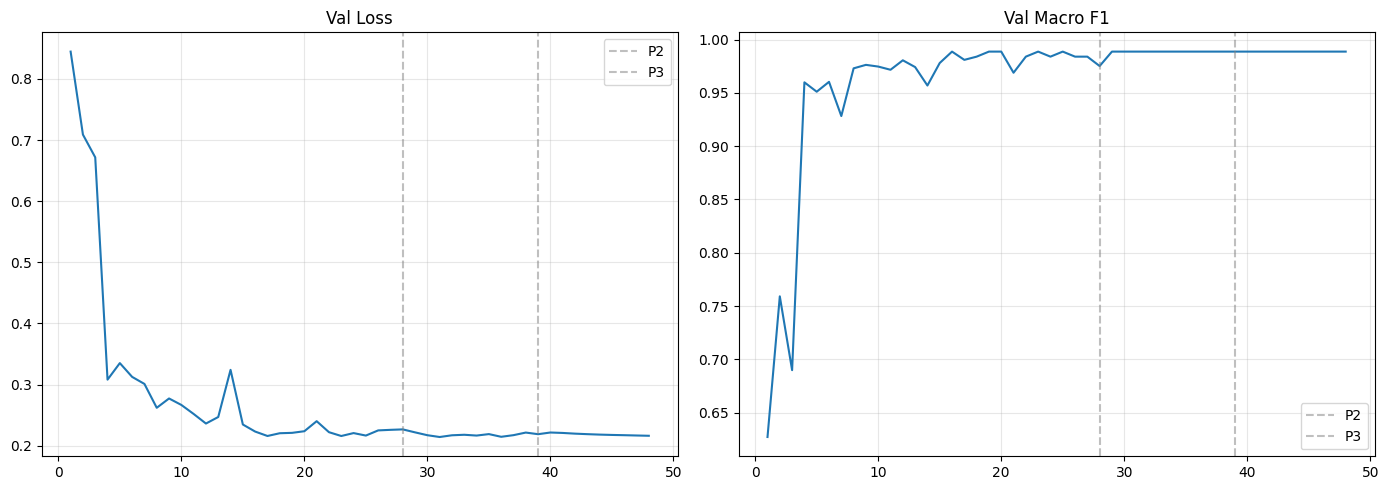

In [13]:
# ── Phase 3: Unfreeze ALL 24 blocks ──────────────────────────
load_ckpt(model, BEST_CKPT)
model.extractor.freeze_visual()
model.extractor.enable_finetune(24)

p3_groups = [
    {'params': [p for p in model.extractor.clip.visual.parameters() if p.requires_grad], 'lr': CONFIG['lr_clip_p3']},
    {'params': list(model.gac.parameters()),        'lr': CONFIG['lr_conn_p3']},
    {'params': list(model.classifier.parameters()), 'lr': CONFIG['lr_cls_p3']},
    {'params': list(model.proj_head.parameters()),  'lr': CONFIG['lr_cls_p3']},
]
best_f1_p3, best_path_p3, hist_p3 = run_phase(
    model, train_loader, val_loader, CONFIG,
    CONFIG['phase3_epochs'], p3_groups, 'p3', CONFIG['patience_p3'])

if best_f1_p3 > BEST_F1:
    BEST_CKPT = best_path_p3; BEST_F1 = best_f1_p3
    print(f'Phase 3 improved → {BEST_F1:.4f}')
else:
    print(f'Phase 3 no improve ({best_f1_p3:.4f}), best={BEST_F1:.4f}')

all_hist = hist_p1 + hist_p2 + hist_p3
ep = range(1, len(all_hist)+1)
p1e, p2e = len(hist_p1), len(hist_p1)+len(hist_p2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, title in [(axes[0], 'vl', 'Val Loss'), (axes[1], 'vf', 'Val Macro F1')]:
    ax.plot(ep, [h[key] for h in all_hist])
    for xv, lbl in [(p1e,'P2'),(p2e,'P3')]:
        ax.axvline(xv, color='gray', ls='--', alpha=0.5, label=lbl)
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/curves.png", dpi=120, bbox_inches='tight'); plt.show()

---
### Zero-Shot + K-NN

1. `INFER_BATCH=16`: Setelah Phase 3, hampir seluruh 141 GB VRAM terisi model. Batch kecil untuk inference mencegah OOM.

2. `_cls_buf.clear()` di `encode_image_for_zs()`: Fix critical bug — hooks yang terdaftar di setiap ResidualAttentionBlock terus-menerus mengisi _cls_buf. Tanpa clear, setiap batch menambah 24 tensor ke buffer, menyebabkan memory leak yang akhirnya OOM.

3. `torch.cuda.empty_cache()` di antara setiap step: Membebaskan fragment memory yang tidak terpakai di CUDA allocator.

4. Zero-Shot CLIP: Menggunakan text encoder CLIP untuk generate class prototypes dari text prompts. Tidak butuh training — memanfaatkan pengetahuan visual-language yang sudah ada di CLIP. Berguna terutama untuk kelas fake_unknown yang tidak memiliki visual pattern yang konsisten.

5. K-NN (k=15, temperature=15): Instance-based prediction menggunakan cosine similarity di CLIP feature space. Temperature-weighted voting (exp(sim × 15)) memberi bobot lebih besar ke neighbor yang lebih dekat. K=15 memberikan keseimbangan antara bias (terlalu kecil → noise sensitive) dan variance (terlalu besar → underfitting).

In [14]:
# ── Zero-Shot + K-NN ─────────────────────────────────────────
load_ckpt(model, BEST_CKPT)
torch.cuda.empty_cache()

@torch.no_grad()
def predict_tta(model, df_test, image_size, batch_size, tta_steps):
    model.eval()
    all_probs = []
    for i, tfm in enumerate(get_tta_transforms(image_size)[:tta_steps]):
        ds = FASDataset(df_test, transform=tfm, is_test=True)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
        probs = []
        for imgs, _ in tqdm(loader, desc=f'  TTA {i+1}/{tta_steps}', leave=False):
            with autocast(AMP_DEVICE):
                logits, _ = model(imgs.to(DEVICE, non_blocking=True))
            probs.append(F.softmax(logits, dim=1).cpu().numpy())
        all_probs.append(np.concatenate(probs, axis=0))
    return np.mean(all_probs, axis=0)


@torch.no_grad()
def zero_shot_predict(model, df_test, image_size, batch_size, text_feats):
    model.eval()
    ds = FASDataset(df_test, get_val_transform(image_size), is_test=True)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    all_probs = []
    for imgs, _ in tqdm(loader, desc='  ZeroShot', leave=False):
        img_f = model.extractor.encode_image_for_zs(imgs.to(DEVICE, non_blocking=True))
        probs = F.softmax(img_f @ text_feats.T * 100.0, dim=1)
        all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs, axis=0)


@torch.no_grad()
def extract_feats(model, df, image_size, batch_size, is_test=False):
    model.eval()
    ds = FASDataset(df, get_val_transform(image_size), is_test=is_test)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    feats = []
    for batch in tqdm(loader, desc='  Feats', leave=False):
        imgs = batch[0].to(DEVICE, non_blocking=True)
        feats.append(model.extractor.encode_image_for_zs(imgs).cpu().numpy())
    return np.concatenate(feats, axis=0)


def knn_predict(tr_feats, tr_labels, te_feats, k=15, n_classes=6):
    sim = tr_feats @ te_feats.T
    top_k = np.argsort(-sim, axis=0)[:k, :]
    probs = np.zeros((te_feats.shape[0], n_classes))
    for j in range(te_feats.shape[0]):
        nl = tr_labels[top_k[:, j]]
        ws = np.exp(sim[top_k[:, j], j] * 15)
        for lbl, w in zip(nl, ws): probs[j, lbl] += w
        probs[j] /= probs[j].sum() + 1e-8
    return probs


print('Computing Zero-Shot, K-NN, and NN TTA...')
text_feats   = model.extractor.encode_text_prompts(TEXT_PROMPTS)
zs_probs     = zero_shot_predict(model, test_df, CONFIG['image_size'], INFER_BATCH, text_feats)
torch.cuda.empty_cache()
train_feats  = extract_feats(model, train_df, CONFIG['image_size'], INFER_BATCH)
torch.cuda.empty_cache()
test_feats   = extract_feats(model, test_df,  CONFIG['image_size'], INFER_BATCH, is_test=True)
torch.cuda.empty_cache()
knn_probs    = knn_predict(train_feats, train_df['label_idx'].values, test_feats, k=15)
nn_probs     = predict_tta(model, test_df, CONFIG['image_size'], INFER_BATCH, CONFIG['tta_steps'])
print('Done.')

Computing Zero-Shot, K-NN, and NN TTA...


  ZeroShot:   0%|          | 0/26 [00:00<?, ?it/s]

  Feats:   0%|          | 0/103 [00:00<?, ?it/s]

  Feats:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 1/20:   0%|          | 0/26 [00:00<?, ?it/s]

...

  TTA 17/20:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 18/20:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 19/20:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 20/20:   0%|          | 0/26 [00:00<?, ?it/s]

Done.


---
### Pseudo-labeling Round 1 (threshold=0.998). 

Prediksi test set dengan model saat ini, ambil sampel dengan confidence ≥ 0.998 sebagai pseudo-labels, tambahkan ke training set, retrain.

> Round 1 hanya mengambil prediksi yang hampir pasti benar. Noise di pseudo-labels sangat merusak — model yang retrain dengan label salah akan memperparah kesalahan (confirmation bias). Threshold tinggi memastikan hanya ~top 1% most confident predictions yang digunakan, meminimalkan noise sambil menambah sedikit data.

In [15]:
# ── Pseudo-labeling Round 1 ───────────────────────────────────
def make_pseudo_df(probs, test_df, train_df, threshold):
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    mask = conf >= threshold
    print(f'Pseudo (>={threshold}): {mask.sum()}/{len(test_df)}')
    rows = []
    for i in np.where(mask)[0]:
        row = test_df.iloc[i].to_dict()
        row['label'] = IDX2CLASS[pred[i]]; row['label_idx'] = int(pred[i])
        rows.append(row)
    if rows:
        aug = pd.concat([train_df, pd.DataFrame(rows)], ignore_index=True)
        print(f'Augmented: {len(train_df)} + {len(rows)} = {len(aug)}')
        return aug
    return train_df.copy()


combined  = (CONFIG['w_nn']*nn_probs + CONFIG['w_zs']*zs_probs + CONFIG['w_knn']*knn_probs)
aug_df_r1 = make_pseudo_df(combined, test_df, train_df, CONFIG['pseudo_conf_r1'])

if len(aug_df_r1) > len(train_df):
    atr1, ava1, _ = build_dataloaders(aug_df_r1, CONFIG['image_size'], CONFIG['val_split'],
                                       CONFIG['batch_size'], CONFIG['num_workers'], CONFIG['seed'])
    load_ckpt(model, BEST_CKPT)
    model.extractor.freeze_visual()
    model.extractor.enable_finetune(24)
    ps1_groups = [
        {'params': [p for p in model.extractor.clip.visual.parameters() if p.requires_grad], 'lr': CONFIG['lr_clip_p3']*0.5},
        {'params': list(model.gac.parameters()),        'lr': CONFIG['lr_conn_p3']*0.5},
        {'params': list(model.classifier.parameters()), 'lr': CONFIG['lr_cls_p3']*0.5},
        {'params': list(model.proj_head.parameters()),  'lr': CONFIG['lr_cls_p3']*0.5},
    ]
    f_ps1, path_ps1, _ = run_phase(model, atr1, ava1, CONFIG,
                                    CONFIG['pseudo_epochs_r1'], ps1_groups, 'ps_r1', CONFIG['patience_ps'])
    if f_ps1 > BEST_F1: BEST_CKPT = path_ps1; BEST_F1 = f_ps1; print(f'PS R1 → {BEST_F1:.4f}')
    else: print(f'PS R1 no improve ({f_ps1:.4f})')
else:
    aug_df_r1 = train_df.copy()
    print('No pseudo R1 data.')

print(f'Best after PS R1: {BEST_F1:.4f}')

Pseudo (>=0.998): 0/404
No pseudo R1 data.
Best after PS R1: 0.9888


---
### Pseudo-labeling Round 2 (threshold=0.97)

Re-predict dengan model terbaru, ambil confidence ≥ 0.97, retrain.

> Setelah Round 1, model sudah lebih baik sehingga prediksinya lebih reliabel. Threshold 0.97 mengambil lebih banyak pseudo-labels dengan risiko noise yang masih terkontrol. LR di-set 0.3× dari Phase 3 (bukan 0.5× seperti Round 1) karena model sudah sangat fine-tuned — update terlalu besar bisa merusak.

In [16]:
# ── Pseudo-labeling Round 2 ───────────────────────────────────
load_ckpt(model, BEST_CKPT)
torch.cuda.empty_cache()

nn_p2   = predict_tta(model, test_df, CONFIG['image_size'], INFER_BATCH, 7)
tf2     = model.extractor.encode_text_prompts(TEXT_PROMPTS)
zs_p2   = zero_shot_predict(model, test_df, CONFIG['image_size'], INFER_BATCH, tf2)
torch.cuda.empty_cache()
tr_f2   = extract_feats(model, train_df, CONFIG['image_size'], INFER_BATCH)
torch.cuda.empty_cache()
te_f2   = extract_feats(model, test_df,  CONFIG['image_size'], INFER_BATCH, is_test=True)
torch.cuda.empty_cache()
knn_p2  = knn_predict(tr_f2, train_df['label_idx'].values, te_f2, k=15)
comb2   = (CONFIG['w_nn']*nn_p2 + CONFIG['w_zs']*zs_p2 + CONFIG['w_knn']*knn_p2)

aug_df_r2 = make_pseudo_df(comb2, test_df, train_df, CONFIG['pseudo_conf_r2'])

if len(aug_df_r2) > len(train_df):
    atr2, ava2, _ = build_dataloaders(aug_df_r2, CONFIG['image_size'], CONFIG['val_split'],
                                       CONFIG['batch_size'], CONFIG['num_workers'], CONFIG['seed'])
    load_ckpt(model, BEST_CKPT)
    model.extractor.freeze_visual()
    model.extractor.enable_finetune(24)
    ps2_groups = [
        {'params': [p for p in model.extractor.clip.visual.parameters() if p.requires_grad], 'lr': CONFIG['lr_clip_p3']*0.3},
        {'params': list(model.gac.parameters()),        'lr': CONFIG['lr_conn_p3']*0.3},
        {'params': list(model.classifier.parameters()), 'lr': CONFIG['lr_cls_p3']*0.3},
        {'params': list(model.proj_head.parameters()),  'lr': CONFIG['lr_cls_p3']*0.3},
    ]
    f_ps2, path_ps2, _ = run_phase(model, atr2, ava2, CONFIG,
                                    CONFIG['pseudo_epochs_r2'], ps2_groups, 'ps_r2', CONFIG['patience_ps'])
    if f_ps2 > BEST_F1: BEST_CKPT = path_ps2; BEST_F1 = f_ps2; print(f'PS R2 → {BEST_F1:.4f}')
    else: print(f'PS R2 no improve ({f_ps2:.4f})')
else:
    aug_df_r2 = aug_df_r1.copy()
    print('No pseudo R2 data.')

print(f'Best after PS R2: {BEST_F1:.4f}')

  TTA 1/7:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 2/7:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 3/7:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 4/7:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 5/7:   0%|          | 0/26 [00:00<?, ?it/s]

...

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   5/10 | TL=0.7168 TF=0.8223 | VL=0.2151 VF=0.9892 VA=0.9882 | 32s


  Train:   0%|          | 0/23 [00:00<?, ?it/s]

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   6/10 | TL=0.6186 TF=0.7352 | VL=0.2149 VF=0.9892 VA=0.9882 | 33s
  Early stop ep 6
  ps_r2 best F1: 0.9892
PS R2 → 0.9892
Best after PS R2: 0.9892


---
### Pseudo-labeling Round 3 (threshold=0.92)

Round terakhir dengan threshold paling rendah (0.92).

> Dengan 3 round pseudo-labeling, model secara iteratif memanfaatkan test data untuk memperbaiki dirinya sendiri — semacam semi-supervised learning. LR di Round 3 hanya 0.2× dari Phase 3, sangat konservatif. Threshold 0.92 masih cukup selektif (top ~8% confidence) untuk menghindari terlalu banyak noise.

In [17]:
# ── Pseudo-labeling Round 3 (lower threshold) ─────────────────
load_ckpt(model, BEST_CKPT)
torch.cuda.empty_cache()

nn_p3   = predict_tta(model, test_df, CONFIG['image_size'], INFER_BATCH, 7)
tf3     = model.extractor.encode_text_prompts(TEXT_PROMPTS)
zs_p3   = zero_shot_predict(model, test_df, CONFIG['image_size'], INFER_BATCH, tf3)
torch.cuda.empty_cache()
tr_f3   = extract_feats(model, train_df, CONFIG['image_size'], INFER_BATCH)
torch.cuda.empty_cache()
te_f3   = extract_feats(model, test_df,  CONFIG['image_size'], INFER_BATCH, is_test=True)
torch.cuda.empty_cache()
knn_p3  = knn_predict(tr_f3, train_df['label_idx'].values, te_f3, k=15)
comb3   = (CONFIG['w_nn']*nn_p3 + CONFIG['w_zs']*zs_p3 + CONFIG['w_knn']*knn_p3)

aug_df_r3 = make_pseudo_df(comb3, test_df, train_df, CONFIG['pseudo_conf_r3'])

if len(aug_df_r3) > len(train_df):
    atr3, ava3, _ = build_dataloaders(aug_df_r3, CONFIG['image_size'], CONFIG['val_split'],
                                       CONFIG['batch_size'], CONFIG['num_workers'], CONFIG['seed'])
    load_ckpt(model, BEST_CKPT)
    model.extractor.freeze_visual()
    model.extractor.enable_finetune(24)
    ps3_groups = [
        {'params': [p for p in model.extractor.clip.visual.parameters() if p.requires_grad], 'lr': CONFIG['lr_clip_p3']*0.2},
        {'params': list(model.gac.parameters()),        'lr': CONFIG['lr_conn_p3']*0.2},
        {'params': list(model.classifier.parameters()), 'lr': CONFIG['lr_cls_p3']*0.2},
        {'params': list(model.proj_head.parameters()),  'lr': CONFIG['lr_cls_p3']*0.2},
    ]
    f_ps3, path_ps3, _ = run_phase(model, atr3, ava3, CONFIG,
                                    CONFIG['pseudo_epochs_r3'], ps3_groups, 'ps_r3', CONFIG['patience_ps'])
    if f_ps3 > BEST_F1: BEST_CKPT = path_ps3; BEST_F1 = f_ps3; print(f'PS R3 → {BEST_F1:.4f}')
    else: print(f'PS R3 no improve ({f_ps3:.4f})')
else:
    aug_df_r3 = aug_df_r2.copy()
    print('No pseudo R3 data.')

print(f'Best after PS R3: {BEST_F1:.4f}')

  TTA 1/7:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 2/7:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 3/7:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 4/7:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 5/7:   0%|          | 0/26 [00:00<?, ?it/s]

...

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   5/8 | TL=0.6217 TF=0.8520 | VL=0.2029 VF=0.9946 VA=0.9943 | 31s


  Train:   0%|          | 0/24 [00:00<?, ?it/s]

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

  Ep   6/8 | TL=0.6035 TF=0.6358 | VL=0.2028 VF=0.9946 VA=0.9943 | 28s
  Early stop ep 6
  ps_r3 best F1: 0.9946
PS R3 → 0.9946
Best after PS R3: 0.9946


---
### 4-Model Ensemble

Training 3 model tambahan dengan seeds berbeda (123, 456, 999), semua melalui 3-phase training penuh, kemudian predict test set dengan TTA.

Kenapa 4 model dengan seed berbeda:

- Diversity: Seed berbeda menghasilkan initialization dan data shuffling yang berbeda, sehingga setiap model membuat kesalahan yang berbeda-beda.

- Averaging errors: Rata-rata prediksi beberapa model yang independent mengurangi variance prediksi (mirip prinsip bagging). Secara teoritis, jika error antar model tidak berkorelasi, ensemble N model mengurangi variance sebesar N×.

- 3-phase penuh per model: Setiap model ensemble juga melalui frozen→partial→full fine-tuning untuk memastikan kualitas yang setara dengan main model.

- use_df menggunakan data yang sudah di-augment dengan pseudo-labels (hasil round terbaik) sehingga semua model ensemble juga memanfaatkan pseudo-labels.


In [18]:
# ── 4-Model NN Ensemble ───────────────────────────────────────
extra_nn_probs  = []
ENSEMBLE_SEEDS  = [123, 456, 999]
use_df = aug_df_r3 if len(aug_df_r3) > len(train_df) else train_df

for seed in ENSEMBLE_SEEDS:
    set_seed(seed)
    ecfg = {**CONFIG}
    print(f'\n{"="*65}\n  Ensemble seed={seed}\n{"="*65}')

    etr, eva, _ = build_dataloaders(use_df, ecfg['image_size'], ecfg['val_split'],
                                    ecfg['batch_size'], ecfg['num_workers'], seed)
    em = IFASModelV5(ecfg).to(DEVICE)

    # Phase 1
    ep1g = [{'params': list(em.gac.parameters()),        'lr': ecfg['lr_connector']},
            {'params': list(em.classifier.parameters()), 'lr': ecfg['lr_classifier']},
            {'params': list(em.proj_head.parameters()),  'lr': ecfg['lr_classifier']}]
    ef1, ep1p, _ = run_phase(em, etr, eva, ecfg, ecfg['phase1_epochs'],
                             ep1g, f's{seed}_p1', ecfg['patience_p1'])

    # Phase 2
    load_ckpt(em, ep1p)
    em.extractor.enable_finetune(ecfg['n_unfreeze_p2'])
    ep2g = [{'params': [p for p in em.extractor.clip.visual.parameters() if p.requires_grad], 'lr': ecfg['lr_clip_p2']},
            {'params': list(em.gac.parameters()),        'lr': ecfg['lr_conn_p2']},
            {'params': list(em.classifier.parameters()), 'lr': ecfg['lr_cls_p2']},
            {'params': list(em.proj_head.parameters()),  'lr': ecfg['lr_cls_p2']}]
    ef2, ep2p, _ = run_phase(em, etr, eva, ecfg, ecfg['phase2_epochs'],
                             ep2g, f's{seed}_p2', ecfg['patience_p2'])

    # Phase 3
    best_ep = ep2p if ef2 >= ef1 else ep1p
    load_ckpt(em, best_ep)
    em.extractor.freeze_visual()
    em.extractor.enable_finetune(24)
    ep3g = [{'params': [p for p in em.extractor.clip.visual.parameters() if p.requires_grad], 'lr': ecfg['lr_clip_p3']},
            {'params': list(em.gac.parameters()),        'lr': ecfg['lr_conn_p3']},
            {'params': list(em.classifier.parameters()), 'lr': ecfg['lr_cls_p3']},
            {'params': list(em.proj_head.parameters()),  'lr': ecfg['lr_cls_p3']}]
    ef3, ep3p, _ = run_phase(em, etr, eva, ecfg, ecfg['phase3_epochs'],
                             ep3g, f's{seed}_p3', ecfg['patience_p3'])

    final_ep = ep3p if ef3 >= max(ef1, ef2) else best_ep
    load_ckpt(em, final_ep)
    torch.cuda.empty_cache()
    ep = predict_tta(em, test_df, ecfg['image_size'], INFER_BATCH, ecfg['tta_steps'])
    extra_nn_probs.append(ep)
    del em; torch.cuda.empty_cache()
    print(f'Ensemble seed={seed} done.')

print(f'\nTotal ensemble models: {1+len(extra_nn_probs)}')


  Ensemble seed=123
Train 1579 | Val 176
CLIP: D=1024, L=24

  s123_p1 — 35 epochs max


  Train:   0%|          | 0/24 [00:02<?, ?it/s]

  Val:   0%|          | 0/2 [00:01<?, ?it/s]

  Ep   1/35 | TL=1.7540 TF=0.1733 | VL=0.8490 VF=0.5593 VA=0.5852 | 30s
  *** /outputs/v5/s123_p1_f10.5593_ep1.pth


  Train:   0%|          | 0/24 [00:00<?, ?it/s]

...

  TTA 17/20:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 18/20:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 19/20:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 20/20:   0%|          | 0/26 [00:00<?, ?it/s]

Ensemble seed=999 done.

Total ensemble models: 4


---
### Final Prediction

Load `BEST_CKPT`, prediksi ulang dengan 20-step TTA, re-compute ZS dan KNN, rata-rata semua 4 NN models, final blend, save submission5.csv.

Formula final blend:
`0.55 × NN_ensemble + 0.25 × ZeroShot + 0.20 × KNN`

- NN diberi bobot tertinggi karena trained on task-specific data.
- ZeroShot diberi bobot signifikan karena CLIP memiliki semantic knowledge yang tidak ada di training.
- KNN melengkapi dengan instance-based reasoning.

In [19]:
# ── Final prediction ─────────────────────────────────────────
load_ckpt(model, BEST_CKPT)
torch.cuda.empty_cache()
print(f'Main model final TTA (F1={BEST_F1:.4f})...')

nn_final     = predict_tta(model, test_df, CONFIG['image_size'], INFER_BATCH, CONFIG['tta_steps'])
torch.cuda.empty_cache()
text_feats_f = model.extractor.encode_text_prompts(TEXT_PROMPTS)
zs_final     = zero_shot_predict(model, test_df, CONFIG['image_size'], INFER_BATCH, text_feats_f)
torch.cuda.empty_cache()
tr_ft_f      = extract_feats(model, train_df, CONFIG['image_size'], INFER_BATCH)
torch.cuda.empty_cache()
te_ft_f      = extract_feats(model, test_df,  CONFIG['image_size'], INFER_BATCH, is_test=True)
torch.cuda.empty_cache()
knn_final    = knn_predict(tr_ft_f, train_df['label_idx'].values, te_ft_f, k=15)

all_nn       = [nn_final] + extra_nn_probs
nn_ensemble  = np.mean(all_nn, axis=0)
print(f'NN ensemble: {len(all_nn)} models')

final_probs  = (CONFIG['w_nn']  * nn_ensemble +
                CONFIG['w_zs']  * zs_final    +
                CONFIG['w_knn'] * knn_final)

pred_classes = [IDX2CLASS[i] for i in np.argmax(final_probs, axis=1)]
assert all(l in CONFIG['classes'] for l in pred_classes)

sample_sub = pd.read_csv(CONFIG['sample_submission'])
sub_df     = pd.DataFrame({'id': test_df['id'].values, 'label': pred_classes})
sub_df     = sub_df.set_index('id').loc[sample_sub['id']].reset_index()
sub_path   = f"{OUT_DIR}/submission5.csv"
sub_df.to_csv(sub_path, index=False)

print(f'\nSaved: {sub_path}')
print('\nPrediction distribution:')
print(sub_df['label'].value_counts().to_string())

Main model final TTA (F1=0.9946)...


  TTA 1/20:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 2/20:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 3/20:   0%|          | 0/26 [00:00<?, ?it/s]

  TTA 4/20:   0%|          | 0/26 [00:00<?, ?it/s]

...

  TTA 20/20:   0%|          | 0/26 [00:00<?, ?it/s]

  ZeroShot:   0%|          | 0/26 [00:00<?, ?it/s]

  Feats:   0%|          | 0/103 [00:00<?, ?it/s]

  Feats:   0%|          | 0/26 [00:00<?, ?it/s]

NN ensemble: 4 models

Saved: /outputs/v5/submission5.csv

Prediction distribution:
label
realperson        95
fake_mask         74
fake_screen       73
fake_print        63
fake_mannequin    51
fake_unknown      48


---
### Summary & Confusion Matrix

Evaluasi model di validation set, print classification report, plot confusion matrix dan distribusi prediksi test.

  Val:   0%|          | 0/2 [00:00<?, ?it/s]

Val Acc=0.9879  Macro-F1=0.9888
                precision    recall  f1-score   support

    realperson     1.0000    0.9767    0.9882        43
    fake_print     1.0000    1.0000    1.0000        14
   fake_screen     0.9524    1.0000    0.9756        20
     fake_mask     0.9667    1.0000    0.9831        29
fake_mannequin     1.0000    1.0000    1.0000        23
  fake_unknown     1.0000    0.9722    0.9859        36

      accuracy                         0.9879       165
     macro avg     0.9865    0.9915    0.9888       165
  weighted avg     0.9884    0.9879    0.9879       165



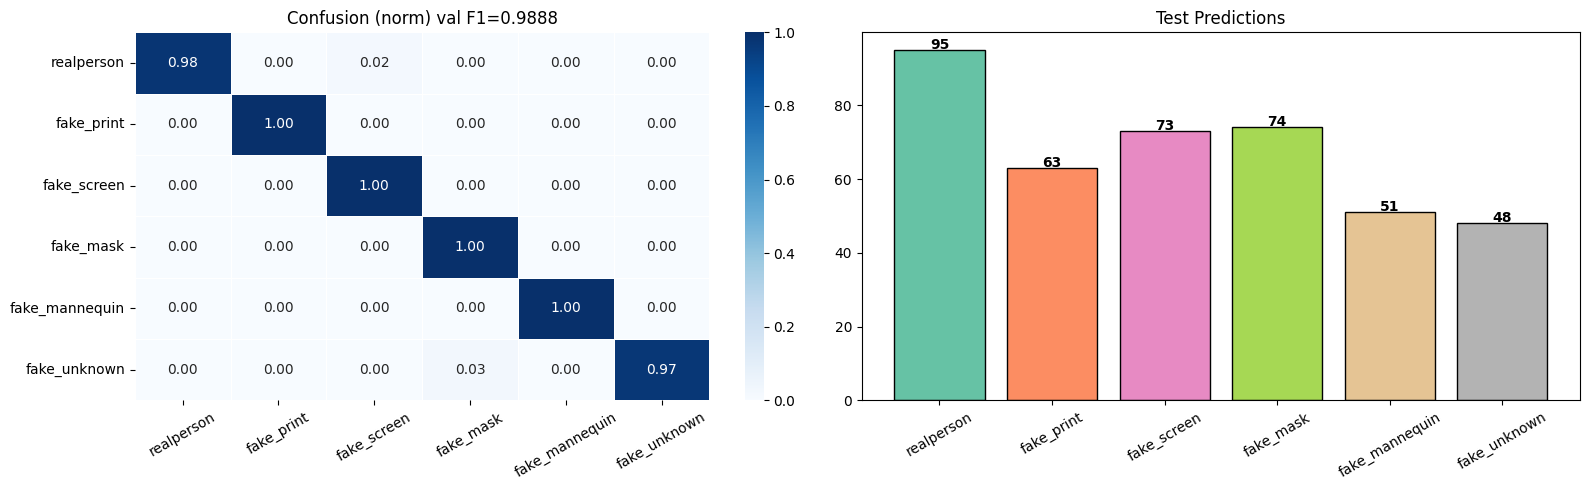

  GPU              : Nvidia H200 141GB
  Model            : ViT-L/14@336px @ 336px
  Best Val F1      : 0.9946
  NN ensemble      : 4 models (seeds: 42,123,456,999)
  + Zero-shot CLIP : weight 0.25
  + K-NN (k=15)    : weight 0.2
  Pseudo-labeling  : 3 rounds
  TTA steps        : 20
  submission5.csv  : /outputs/v5/submission5.csv


In [20]:
# ── Summary & confusion matrix ────────────────────────────────
load_ckpt(model, BEST_CKPT)
_, vf, va, true_l, pred_l = evaluate(model, val_loader)
print(f'Val Acc={va:.4f}  Macro-F1={vf:.4f}')
print(classification_report(true_l, pred_l, target_names=CONFIG['classes'], digits=4))

cm = confusion_matrix(true_l, pred_l)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(cm.astype(float)/cm.sum(axis=1,keepdims=True), annot=True, fmt='.2f',
            cmap='Blues', xticklabels=CONFIG['classes'], yticklabels=CONFIG['classes'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'Confusion (norm) val F1={vf:.4f}'); axes[0].tick_params(axis='x',rotation=30)

tc = sub_df['label'].value_counts().reindex(CONFIG['classes'], fill_value=0)
colors = plt.cm.Set2(np.linspace(0,1,6))
bars = axes[1].bar(tc.index, tc.values, color=colors, edgecolor='black')
for bar, v in zip(bars, tc.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(v), ha='center', fontweight='bold')
axes[1].set_title('Test Predictions'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/final_summary.png', dpi=150, bbox_inches='tight'); plt.show()

with open(f'{OUT_DIR}/history.json', 'w') as f:
    json.dump({'p1': hist_p1, 'p2': hist_p2, 'p3': hist_p3}, f, indent=2)

print('='*65)
print(f'  GPU              : Nvidia H200 141GB')
print(f'  Model            : {CONFIG["model_name"]} @ {CONFIG["image_size"]}px')
print(f'  Best Val F1      : {BEST_F1:.4f}')
print(f'  NN ensemble      : {len(all_nn)} models (seeds: 42,123,456,999)')
print(f'  + Zero-shot CLIP : weight {CONFIG["w_zs"]}')
print(f'  + K-NN (k=15)    : weight {CONFIG["w_knn"]}')
print(f'  Pseudo-labeling  : 3 rounds')
print(f'  TTA steps        : {CONFIG["tta_steps"]}')
print(f'  submission5.csv  : {sub_path}')
print('='*65)

---
Cell dibawah hanya untuk melihat model `BEST_CKPT` dan list semua checkpoint

In [21]:
# ── Lihat checkpoint yang dipakai ─────────────────────────────
print('BEST_CKPT (main model):', BEST_CKPT)
print('Ensemble models used:')
print(f'  seed=123 final:', final_ep if 'final_ep' in dir() else 'unknown')
print(f'  seed=456 final:', final_ep if 'final_ep' in dir() else 'unknown')
print(f'  seed=999 final:', final_ep if 'final_ep' in dir() else 'unknown')
print()
print('Semua checkpoint di /outputs/v5/:')
for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith('.pth'):
        sz = os.path.getsize(f'{OUT_DIR}/{f}') / 1e9
        print(f'  {f}  ({sz:.2f} GB)')

BEST_CKPT (main model): /outputs/v5/ps_r3_f10.9946_ep1.pth
Ensemble models used:
  seed=123 final: /outputs/v5/s999_p3_f10.9851_ep3.pth
  seed=456 final: /outputs/v5/s999_p3_f10.9851_ep3.pth
  seed=999 final: /outputs/v5/s999_p3_f10.9851_ep3.pth

Semua checkpoint di /outputs/v5/:
  p1_f10.6271_ep1.pth  (1.50 GB)
  p1_f10.7591_ep2.pth  (1.50 GB)
  p1_f10.9600_ep4.pth  (1.50 GB)
  p1_f10.9604_ep6.pth  (1.50 GB)
  p1_f10.9731_ep8.pth  (1.50 GB)
  p1_f10.9764_ep9.pth  (1.50 GB)
  p1_f10.9806_ep12.pth  (1.50 GB)
  p1_f10.9888_ep16.pth  (1.50 GB)
  p2_f10.9888_ep1.pth  (1.50 GB)
  p3_f10.9888_ep1.pth  (1.50 GB)
  ps_r2_f10.9892_ep1.pth  (1.50 GB)
  ps_r3_f10.9946_ep1.pth  (1.50 GB)
  s123_p1_f10.5593_ep1.pth  (1.50 GB)
  s123_p1_f10.6318_ep2.pth  (1.50 GB)
  s123_p1_f10.9539_ep3.pth  (1.50 GB)
  s123_p1_f10.9740_ep4.pth  (1.50 GB)
  s123_p1_f10.9829_ep8.pth  (1.50 GB)
  s123_p1_f10.9893_ep11.pth  (1.50 GB)
  s123_p1_f10.9947_ep13.pth  (1.50 GB)
  s123_p2_f10.9947_ep1.pth  (1.50 GB)
  s123_p3

---
Cell dibawah hanya untuk relabel dari `fake_print` menjadi `fake_printed`

In [22]:
# ── Relabel: fake_print -> fake_printed ──────────────────────
sub_relabel = pd.read_csv(f'{OUT_DIR}/submission5.csv')
sub_relabel['label'] = sub_relabel['label'].replace('fake_print', 'fake_printed')
relabel_path = f'{OUT_DIR}/submission5_relabel.csv'
sub_relabel.to_csv(relabel_path, index=False)
print(sub_relabel['label'].value_counts().to_string())
print(f'Saved: {relabel_path}')

label
realperson        95
fake_mask         74
fake_screen       73
fake_printed      63
fake_mannequin    51
fake_unknown      48
Saved: /outputs/v5/submission5_relabel.csv
